# RWA Market Analysis Report

- Data represents:  getting the value of the market by running a (3 minutes engine) for 12 hours. 

- 1- The first chart is showing the price movements (Real-estate total cap/RWA Total cap)
- 2- The second chart  is the Returns chart for the dominance index
- 3- The third one is the rolling standard deviation over the fetching time (window rolling size is 10 ==> "30minutes")
- 4- The total volatility across all the records = 0.13%

### VAR (Value @ Risk):
- Confidence interval = 95%

- Long Positions: Both Parametric and Monte Carlo VaR methods indicate a VaR at approximately -0.21% at a 95% confidence level.
- Short Positions: VaR calculated using Variance-Covariance (Parametric), and Monte Carlo Simulation methods  shows a VaR of 0.21% at a 95% confidence level.

### Conclution 
- The total volatility suggests a `stable market in the normal conditions.`

### Uploading data

In [20]:
import pandas as pd
data = pd.read_csv('real_estate_dominance.csv')
df = pd.DataFrame(data)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

In [21]:
df

,Real_Estate_Dominance
Datetime,
2024-07-04 01:58:04.587741,2.447504
2024-07-04 02:01:33.889985,2.445108
2024-07-04 02:04:58.252151,2.446199
2024-07-04 02:08:18.759868,2.451840
2024-07-04 02:11:34.365170,2.457420
...,...
2024-07-04 14:37:26.264447,2.432681
2024-07-04 14:40:43.981039,2.431131
2024-07-04 14:44:01.806377,2.434881


In [22]:
# Calculating returns
df['Returns'] = df['Real_Estate_Dominance'].pct_change()
df

,Real_Estate_Dominance,Returns
Datetime,,
2024-07-04 01:58:04.587741,2.447504,NaN
2024-07-04 02:01:33.889985,2.445108,-0.000979
2024-07-04 02:04:58.252151,2.446199,0.000446
2024-07-04 02:08:18.759868,2.451840,0.002306
2024-07-04 02:11:34.365170,2.457420,0.002276
...,...,...
2024-07-04 14:37:26.264447,2.432681,-0.000998
2024-07-04 14:40:43.981039,2.431131,-0.000637
2024-07-04 14:44:01.806377,2.434881,0.001543


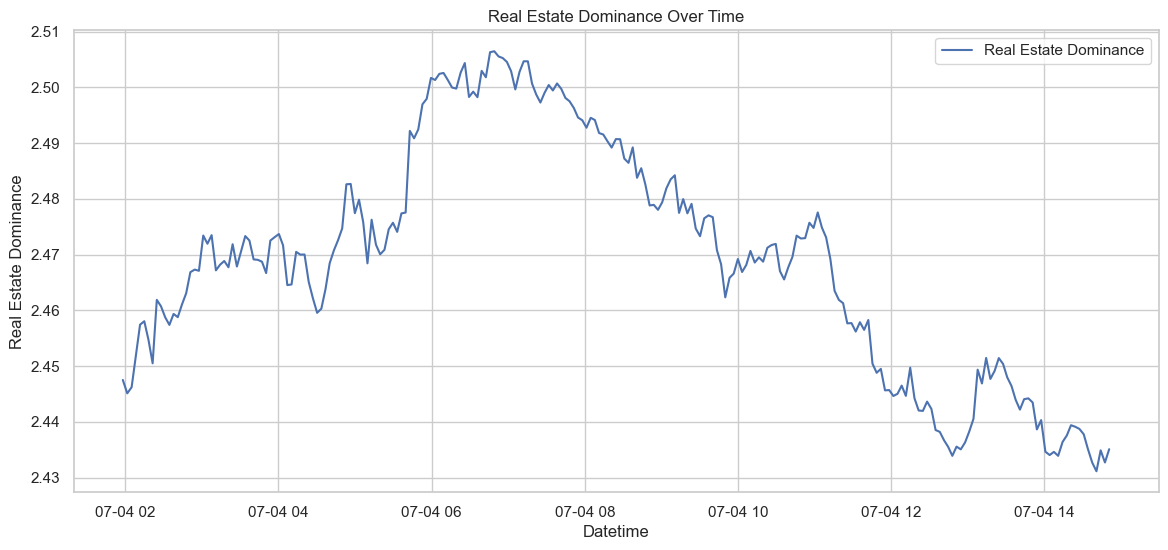

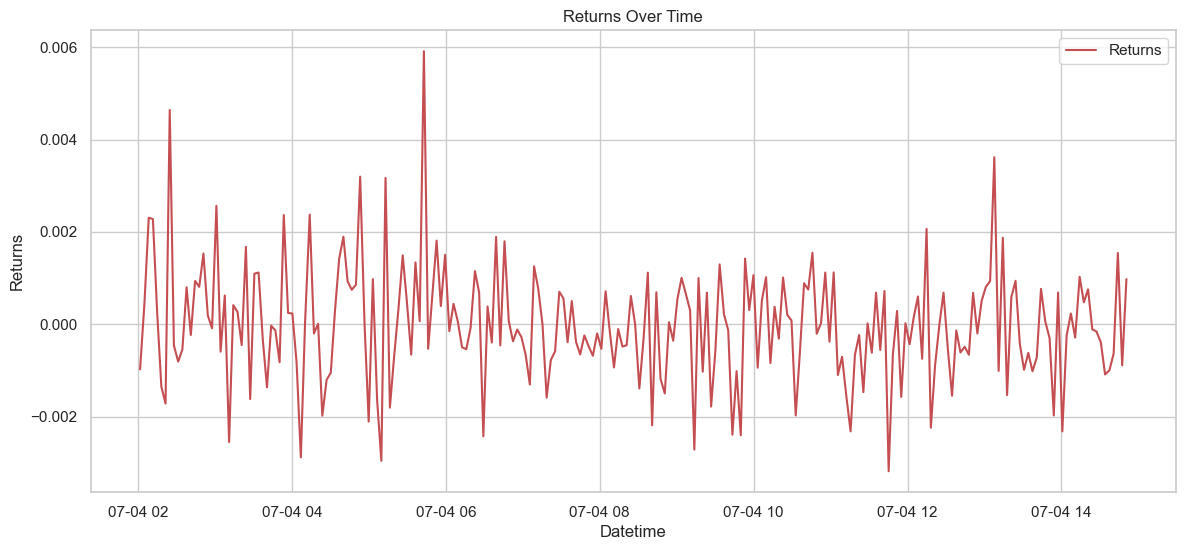

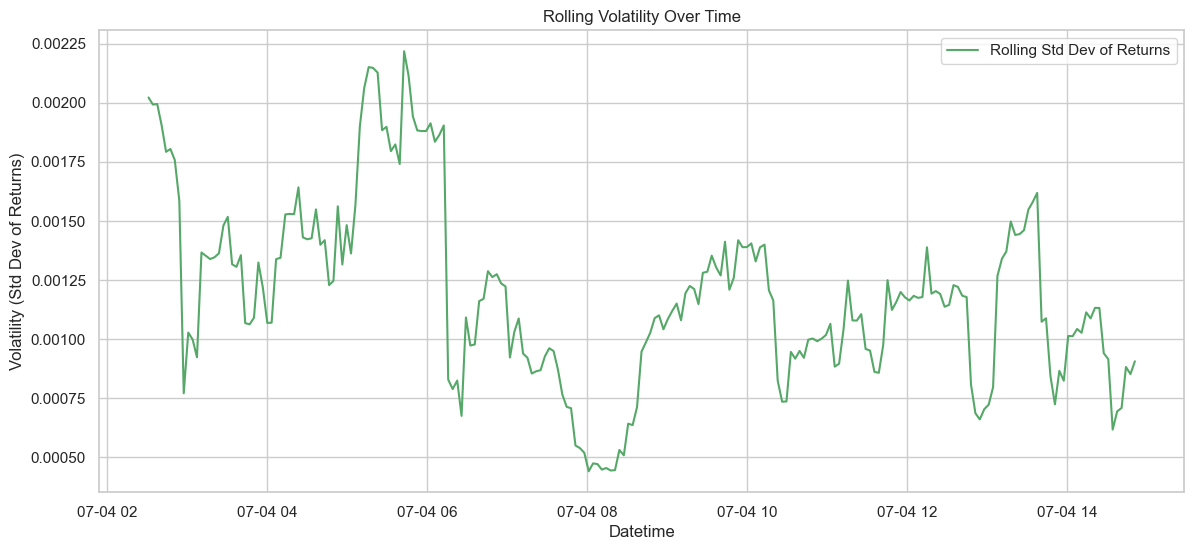

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the plots
sns.set(style="whitegrid")

#Real Estate Dominance over Time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Real_Estate_Dominance'], marker='', color='b', linewidth=1.5, label='Real Estate Dominance')
plt.title('Real Estate Dominance Over Time')
plt.xlabel('Datetime')
plt.ylabel('Real Estate Dominance')
plt.legend()
plt.grid(True)
plt.show()

# Returns over Time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Returns'], marker='', color='r', linewidth=1.5, label='Returns')
plt.title('Returns Over Time')
plt.xlabel('Datetime')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

# Volatility (Standard Deviation of Returns) over Time

# Calculate rolling standard deviation
rolling_window = 10  
df['Rolling_Std'] = df['Returns'].rolling(window=rolling_window).std()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Rolling_Std'], marker='', color='g', linewidth=1.5, label='Rolling Std Dev of Returns')
plt.title('Rolling Volatility Over Time')
plt.xlabel('Datetime')
plt.ylabel('Volatility (Std Dev of Returns)')
plt.legend()
plt.grid(True)
plt.show()


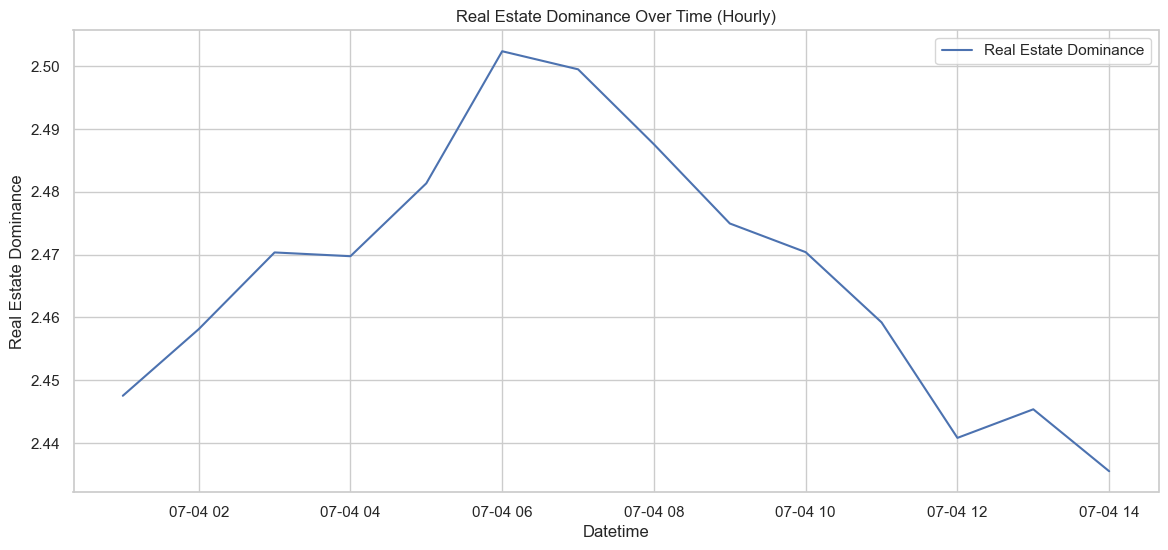

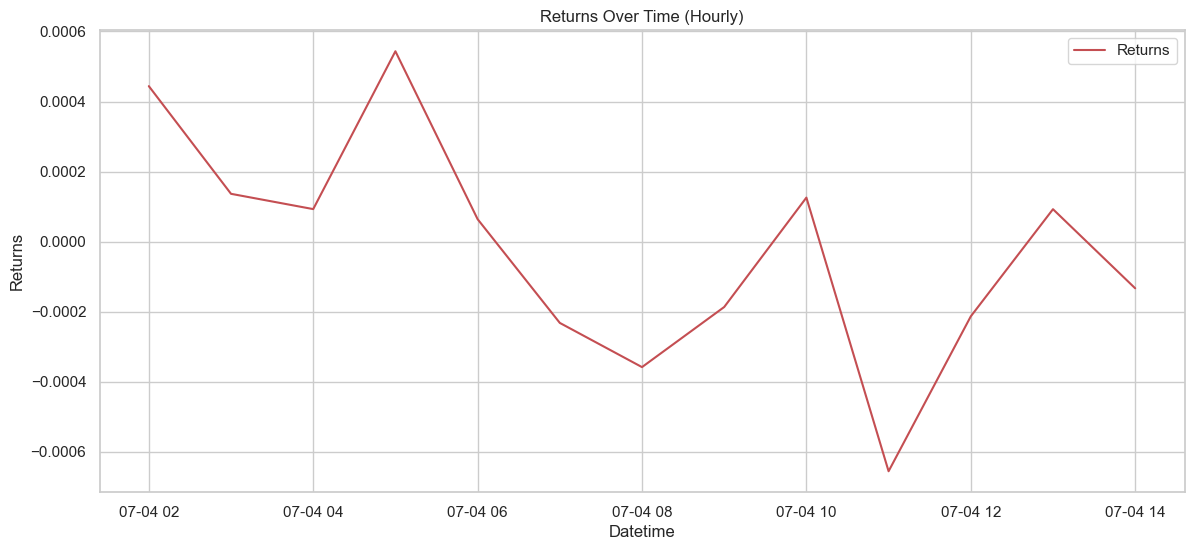

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resample the data to hourly frequency
df_resampled = df.resample('h').mean()

# Set the style of the plots
sns.set(style="whitegrid")

# Real Estate Dominance over Time
plt.figure(figsize=(14, 6))
plt.plot(df_resampled.index, df_resampled['Real_Estate_Dominance'], marker='', color='b', linewidth=1.5, label='Real Estate Dominance')
plt.title('Real Estate Dominance Over Time (Hourly)')
plt.xlabel('Datetime')
plt.ylabel('Real Estate Dominance')
plt.legend()
plt.grid(True)
plt.show()

# Returns over Time
plt.figure(figsize=(14, 6))
plt.plot(df_resampled.index, df_resampled['Returns'], marker='', color='r', linewidth=1.5, label='Returns')
plt.title('Returns Over Time (Hourly)')
plt.xlabel('Datetime')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()


## Entier Period Volatility

In [25]:
fixed_std = df['Returns'].std()

print(f"Entier period volatility: {fixed_std:.4f}")

Entier period volatility: 0.0013


# Var (Value at risk) analyssis
### estimated potential maximum loss in the value over a specific time period with a certain level of confidence

## (95% Confidence interval)

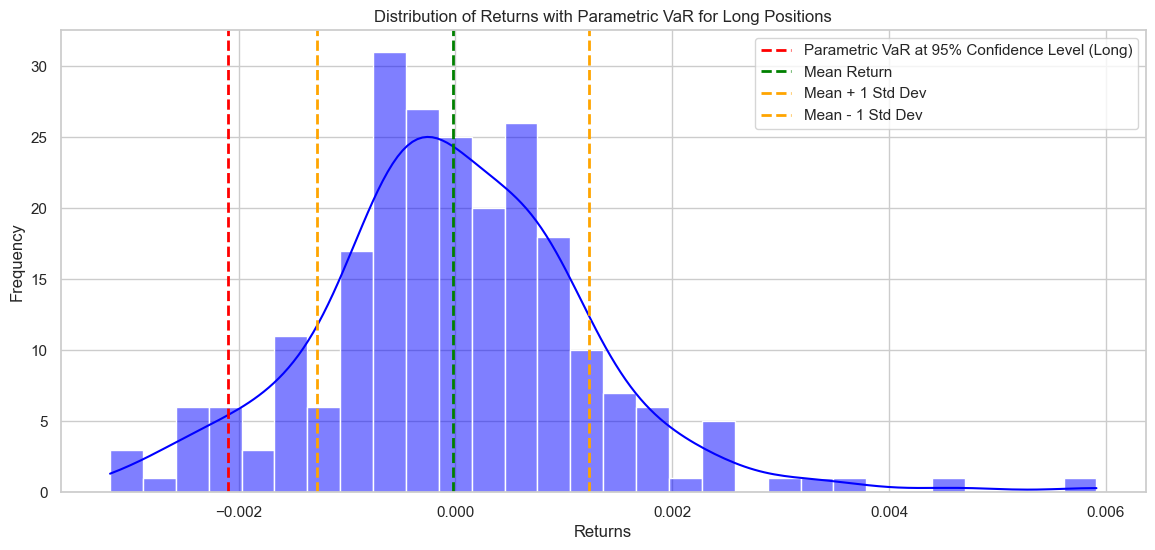

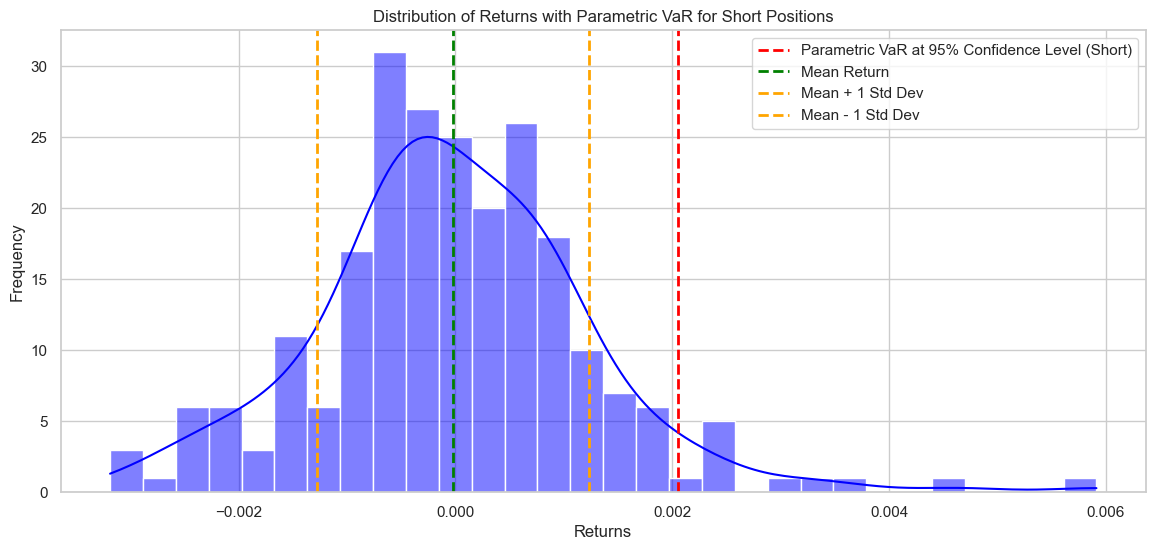

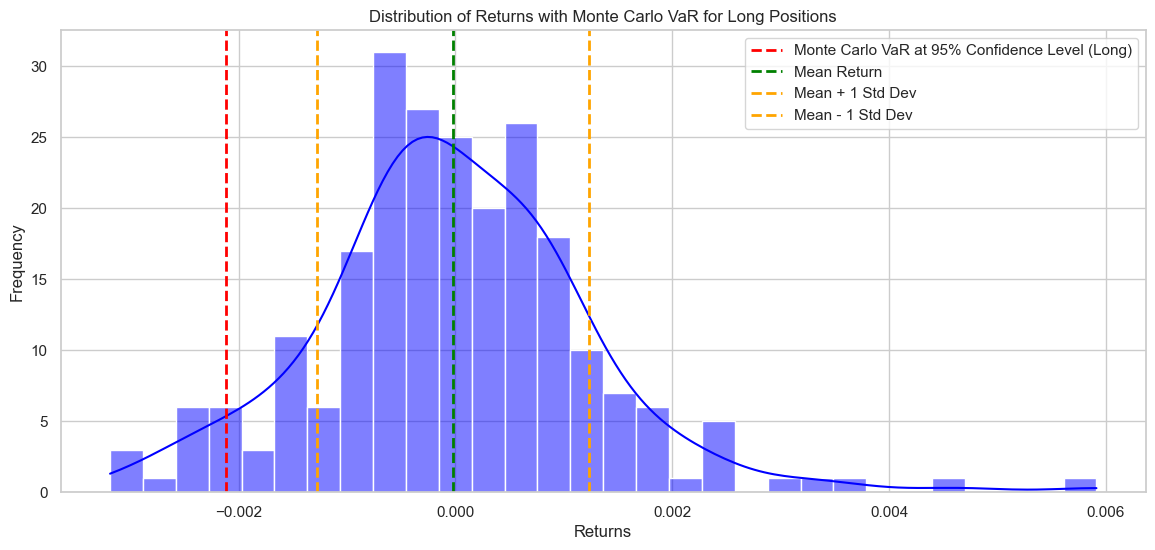

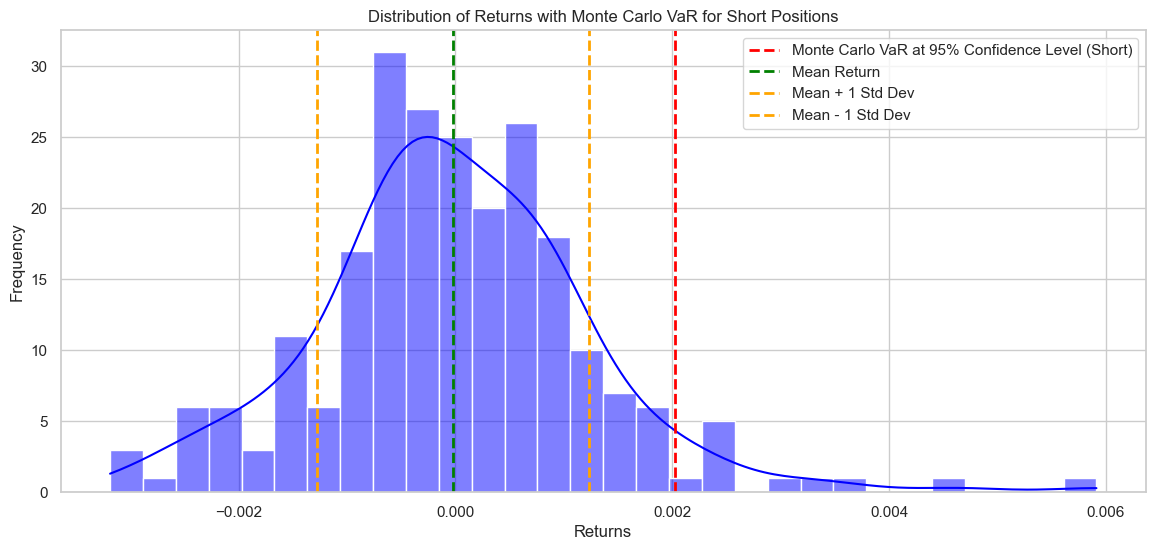

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the fixed standard deviation of returns
fixed_std = df['Returns'].std()
mean_return = df['Returns'].mean()

# Parametric VaR calculation (Variance-Covariance method)
z_score = -1.65  # For 95% confidence level (one-tailed)
var_parametric_long = mean_return + z_score * fixed_std
var_parametric_short = mean_return - z_score * fixed_std

# Monte Carlo Simulation
n_simulations = 10000
simulated_returns = np.random.normal(mean_return, fixed_std, n_simulations)
var_monte_carlo_long = np.percentile(simulated_returns, 5)
var_monte_carlo_short = np.percentile(simulated_returns, 95)

# Visualize the VaR for Long and Short Positions using Parametric Method
sns.set(style="whitegrid")

# Plot 1: Histogram of Returns with Parametric VaR for Long Positions
plt.figure(figsize=(14, 6))
sns.histplot(df['Returns'].dropna(), bins=30, kde=True, color='blue')
plt.axvline(var_parametric_long, color='red', linestyle='dashed', linewidth=2, label='Parametric VaR at 95% Confidence Level (Long)')
plt.axvline(mean_return, color='green', linestyle='dashed', linewidth=2, label='Mean Return')
plt.axvline(mean_return + fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean + 1 Std Dev')
plt.axvline(mean_return - fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean - 1 Std Dev')
plt.title('Distribution of Returns with Parametric VaR for Long Positions')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig('parametric_var_long.png')
plt.show()

# Plot 2: Histogram of Returns with Parametric VaR for Short Positions
plt.figure(figsize=(14, 6))
sns.histplot(df['Returns'].dropna(), bins=30, kde=True, color='blue')
plt.axvline(var_parametric_short, color='red', linestyle='dashed', linewidth=2, label='Parametric VaR at 95% Confidence Level (Short)')
plt.axvline(mean_return, color='green', linestyle='dashed', linewidth=2, label='Mean Return')
plt.axvline(mean_return + fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean + 1 Std Dev')
plt.axvline(mean_return - fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean - 1 Std Dev')
plt.title('Distribution of Returns with Parametric VaR for Short Positions')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig('parametric_var_short.png')
plt.show()

# Visualize the VaR for Long and Short Positions using Monte Carlo Simulation
# Plot 3: Histogram of Returns with Monte Carlo VaR for Long Positions
plt.figure(figsize=(14, 6))
sns.histplot(df['Returns'].dropna(), bins=30, kde=True, color='blue')
plt.axvline(var_monte_carlo_long, color='red', linestyle='dashed', linewidth=2, label='Monte Carlo VaR at 95% Confidence Level (Long)')
plt.axvline(mean_return, color='green', linestyle='dashed', linewidth=2, label='Mean Return')
plt.axvline(mean_return + fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean + 1 Std Dev')
plt.axvline(mean_return - fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean - 1 Std Dev')
plt.title('Distribution of Returns with Monte Carlo VaR for Long Positions')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig('monte_carlo_var_long.png')
plt.show()

# Plot 4: Histogram of Returns with Monte Carlo VaR for Short Positions
plt.figure(figsize=(14, 6))
sns.histplot(df['Returns'].dropna(), bins=30, kde=True, color='blue')
plt.axvline(var_monte_carlo_short, color='red', linestyle='dashed', linewidth=2, label='Monte Carlo VaR at 95% Confidence Level (Short)')
plt.axvline(mean_return, color='green', linestyle='dashed', linewidth=2, label='Mean Return')
plt.axvline(mean_return + fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean + 1 Std Dev')
plt.axvline(mean_return - fixed_std, color='orange', linestyle='dashed', linewidth=2, label='Mean - 1 Std Dev')
plt.title('Distribution of Returns with Monte Carlo VaR for Short Positions')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig('monte_carlo_var_short.png')
plt.show()
